# Document-Aware Extraction with Llama Vision

Document-aware extraction notebook for processing invoices, receipts, and bank statements using Llama-3.2-Vision-Instruct.

**Key Features:**
- Document type detection - Automatically identifies invoice, receipt, or bank statement
- YAML-based prompt configuration - Static prompts for each document type
- V100 GPU optimization - ResilientGenerator with 6-tier OOM fallback system
- Universal field extraction - Consistent fields across all document types
- Memory management - Real-time fragmentation detection and cleanup
- Rich console interface - Beautiful formatting and comprehensive status reporting
- Production-ready error handling - Emergency model reload and CPU fallback
- Ground truth validation - Automated accuracy assessment and performance metrics

**Document Types Supported:**
- **Invoices** - Bills, quotes, estimates with line items and totals
- **Receipts** - Purchase confirmations with items and payment details
- **Bank Statements** - Transaction tables with dates and amounts

**Modern Architecture:**
- Modular V100-optimized extractor class
- External configuration files (YAML)
- Comprehensive memory monitoring
- Advanced error recovery systems

# Core Library Imports

Essential imports for Vision Language Model processing, image handling, and data manipulation.

In [1]:
# Standard library imports
import warnings
from pathlib import Path

# Third-party imports
import pandas as pd
import torch
import yaml
from PIL import Image
from rich import print as rprint
from rich.console import Console
from rich.syntax import Syntax
from rich.table import Table
from transformers import AutoProcessor, MllamaForConditionalGeneration

# Local imports - GPU optimization utilities
from common.gpu_optimization import (
    comprehensive_memory_cleanup,
    configure_cuda_memory_allocation,
    optimize_model_for_v100,
)

warnings.filterwarnings('ignore')

rprint("[bold green]✅ Core libraries imported successfully[/bold green]")

✅ Core libraries imported successfully

# Path Configuration and Model Setup

In [2]:
# Configuration for model
MODEL_PATH = "/home/jovyan/nfs_share/models/Llama-3.2-11B-Vision-Instruct"

# Test images - can be any document type
# TEST_IMAGE = "evaluation_data/commbank_flat_simple.png"  # Bank statement
TEST_IMAGE = "evaluation_data/commbank_flat_complex.png"  # Large Bank statement
# TEST_IMAGE = "evaluation_data/anz_statement_001.png"  # Grouped Bank statement
# TEST_IMAGE = "evaluation_data/image_001.png"  # Invoice
# TEST_IMAGE = "evaluation_data/image_002.png"  # Receipt

# Ground truth CSV for evaluation
GROUND_TRUTH_CSV = "evaluation_data/ground_truth.csv"


# Configuration for document type detection and extraction
DETECTION_PROMPT_FILE = "prompts/document_type_detection.yaml"  # Document type detection prompts
DETECTION_PROMPT_KEY = "detection"  # Which detection prompt to use

# Extraction prompt files for each document type
PROMPT_FILES = {
    "INVOICE": "prompts/invoice_extraction.yaml",
    "RECEIPT": "prompts/receipt_extraction.yaml",
    "BANK_STATEMENT": "prompts/bank_statement_extraction.yaml"
}

# Default prompt key for each document type
PROMPT_KEYS = {
    "INVOICE": "standard",
    "RECEIPT": "standard", 
    "BANK_STATEMENT": "flat"
}


# V100 PRODUCTION CONFIGURATION - MODERN APPROACH
USE_QUANTIZATION = True   # Enable BitsAndBytesConfig (modern approach)
DEVICE_MAP = "auto"       # Automatic device mapping
MAX_NEW_TOKENS = 4000     # V100 OPTIMIZED - Prevents OOM
TORCH_DTYPE = "bfloat16"  # V100 COMPATIBLE - More efficient
LOW_CPU_MEM_USAGE = True  # MEMORY EFFICIENT - Essential for V100

# Initialize Rich console
console = Console()
rprint("[bold blue]🚀 Document-Aware Configuration loaded[/bold blue]")
rprint("[yellow]⚠️ V100 Production Mode: Modern BitsAndBytesConfig approach[/yellow]")
rprint(f"[cyan]🎯 TEST IMAGE: {TEST_IMAGE}[/cyan]")
rprint("[green]💡 Document type will be auto-detected[/green]")

# Validate the selected image exists
if Path(TEST_IMAGE).exists():
    rprint(f"[green]✅ Test image found: {Path(TEST_IMAGE).name}[/green]")
else:
    rprint(f"[red]❌ Test image not found: {TEST_IMAGE}[/red]")
    rprint("[yellow]💡 Update TEST_IMAGE path above[/yellow]")

🚀 Document-Aware Configuration loaded

⚠️ V100 Production Mode: Modern BitsAndBytesConfig approach

🎯 TEST IMAGE: evaluation_data/commbank_flat_complex.png

💡 Document type will be auto-detected

✅ Test image found: commbank_flat_complex.png

# Image Selection & Validation

Select and validate the bank statement image for processing, with fallback to available images.

In [3]:
# =============================================================================
# DOCUMENT IMAGE SELECTION & VALIDATION
# =============================================================================

from common.image_validator import validate_document_image

# Validate and display image information
IMAGE_PATH = validate_document_image(TEST_IMAGE)

🎯 Using document image selection...

🎉 Document ready: commbank_flat_complex.png

                📊 Document Image Information                
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property      ┃ Value                                     ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Filename      │ commbank_flat_complex.png                 │
│ Format        │ PNG                                       │
│ Dimensions    │ 900 × 1320 pixels                         │
│ File Size     │ 137.1 KB                                  │
│ Full Path     │ evaluation_data/commbank_flat_complex.png │
│ Document Type │ To be detected...                         │
└───────────────┴───────────────────────────────────────────┘

─────────────────────────────────────────── Document Selection Complete ───────────────────────────────────────────

# Model Loading & Validation

Load the Llama 3.2 Vision model with comprehensive validation and GPU optimization for V100.

In [4]:
# =============================================================================
# MODEL LOADING & VALIDATION - V100 PRODUCTION OPTIMIZED
# =============================================================================

from common.model_loader import load_v100_model

# Load model with V100 optimizations
model, processor = load_v100_model(
    model_path=MODEL_PATH,
    use_quantization=USE_QUANTIZATION,
    device_map=DEVICE_MAP,
    max_new_tokens=MAX_NEW_TOKENS,
    torch_dtype=TORCH_DTYPE,
    low_cpu_mem_usage=LOW_CPU_MEM_USAGE
)

🚀 Loading Llama Vision model with V100 production optimizations...

🔧 Configuring V100-optimized CUDA memory allocation...

🔧 CUDA memory allocation configured: max_split_size_mb:64
💡 Using 64MB memory blocks to reduce fragmentation
📊 Initial CUDA state: Allocated=0.00GB, Reserved=0.00GB


🔧 Configuring V100-optimized 8-bit quantization with BitsAndBytesConfig

✅ V100-optimized BitsAndBytesConfig configured

...

✅ Model compatibility test passed

Performing initial V100 memory cleanup...

🧹 Clearing model caches...
✅ Model caches cleared
🧹 Memory state: Allocated=4.70GB, Reserved=4.75GB, Fragmentation=0.04GB


🎉 V100-optimized model loading and validation complete!

🔧 V100 optimizations active: CPU offload, vision skip, 32MB blocks

# Prompt Engineering

Define the optimized prompt for bank statement transaction extraction with clear visual guidance.

In [5]:
# Import V100-optimized modules 
from common.ground_truth_helpers import get_expected_transaction_count
from common.llama_vision_table_extractor import LlamaVisionTableExtractor

rprint("[bold green]✅ V100-optimized modules imported successfully[/bold green]")

# =============================================================================
# V100 PRODUCTION INITIALIZATION
# =============================================================================

# Initialize the V100-optimized extractor with existing model and processor
rprint("[bold green]🚀 Initializing V100-optimized LlamaVisionTableExtractor...[/bold green]")

try:
    extractor = LlamaVisionTableExtractor(processor=processor, model=model)
    
    # Validate V100 optimization status
    if hasattr(extractor, 'resilient_generator'):
        rprint("[green]✅ ResilientGenerator initialized for V100 OOM protection[/green]")
    else:
        rprint("[red]❌ ResilientGenerator initialization failed[/red]")
        
    rprint("[green]✅ V100-optimized extractor ready for production use![/green]")
    rprint("[cyan]🎯 V100 Features Active:[/cyan]")
    rprint("[cyan]   • ResilientGenerator with 6-tier OOM fallback[/cyan]")
    rprint("[cyan]   • Memory fragmentation detection and cleanup[/cyan]") 
    rprint("[cyan]   • Individual processing for memory stability[/cyan]")
    rprint("[cyan]   • Emergency model reload capabilities[/cyan]")
    rprint("[cyan]   • CPU fallback as ultimate safety net[/cyan]")
    
except Exception as e:
    rprint(f"[red]❌ CRITICAL: V100 extractor initialization failed: {e}[/red]")
    raise

✅ V100-optimized modules imported successfully

🚀 Initializing V100-optimized LlamaVisionTableExtractor...

✅ Using existing model and processor with V100 ResilientGenerator

✅ ResilientGenerator initialized for V100 OOM protection

✅ V100-optimized extractor ready for production use!

...

   • ResilientGenerator with 6-tier OOM fallback

   • Memory fragmentation detection and cleanup

   • Individual processing for memory stability

   • Emergency model reload capabilities

   • CPU fallback as ultimate safety net

# Document Type Detection

Detect the type of document (invoice, receipt, or bank statement) before selecting the appropriate extraction prompt.

In [6]:
# =============================================================================
# DOCUMENT TYPE DETECTION
# =============================================================================

from common.document_detector import detect_document_type

rprint("[bold blue]📋 Document Type Detection[/bold blue]")

# Detect document type using the extractor
DOCUMENT_TYPE = detect_document_type(
    image_path=IMAGE_PATH,
    extractor=extractor,
    detection_prompt_file=DETECTION_PROMPT_FILE,
    prompt_files=PROMPT_FILES,
    detection_prompt_key=DETECTION_PROMPT_KEY
)

console.rule("[bold green]Document Type Detection Complete[/bold green]")

# ============================================================================= 
# DOCUMENT-SPECIFIC PROMPT LOADING FROM YAML
# =============================================================================

from common.prompt_loader import load_document_prompt

rprint("[bold blue]📋 Loading Document-Specific Prompt from YAML[/bold blue]")

# Load document-specific prompt
EXTRACTION_PROMPT, prompt_name, prompt_description = load_document_prompt(
    prompt_files=PROMPT_FILES,
    prompt_keys=PROMPT_KEYS,
    document_type=DOCUMENT_TYPE
)

from common.ground_truth_helpers import get_expected_transaction_count
from common.llama_vision_table_extractor import LlamaVisionTableExtractor

rprint("[bold green]✅ V100-optimized modules imported successfully[/bold green]")


📋 Document Type Detection

✅ Loaded detection prompt: Document Type Detection

🔍 Detecting document type for: commbank_flat_complex.png

🧪 RUNNING V100-OPTIMIZED EXTRACTION TEST

📄 Image: evaluation_data/commbank_flat_complex.png

...

Single transaction table - best for simple flat statements like commbank_flat_simple.png

   1 Extract bank account details and the transaction table from this bank statement.                              
   2                                                                                                               
   3 ## PART 1: BANK ACCOUNT DETAILS                                                                               
   4 Extract the following information from the statement header/summary:                                          
   5                                                                                                               
   6 BANK_NAME: [bank name (NOT supplier name) or NOT_FOUND]                                                       
   7 BANK_BSB_NUMBER: [6-digit BSB (NOT ABN) or NOT_FOUND]                                                         
   8 BANK_ACCOUNT_NUMBER: [account number or NOT_FOUND]                                                            
   9 BANK_ACCOUNT_HOLDER: [account holder name or NOT_FOUND]                                                       
  10 ACCOUNT_OPENING_BALANCE: [first value in the Balance column of transaction table (rightmost monetary column) o
  11 ACCOUNT_CLOSING_BALANCE: [ending balance at end of statement period (look for 'Closing Balance' or final balan
  12 EARLIEST_TRANSACTION_DATE: [first transaction date in Date column of transaction table or NOT_FOUND]          
  13 LATEST_TRANSACTION_DATE: [last transaction date in Date column of transaction table or NOT_FOUND]             
  14                                                                                                               
  15 ## PART 2: TRANSACTION TABLE                                                                                  
  16 Create a SINGLE markdown table with ALL transactions.                                                         
  17                                                                                                               
  18 IMPORTANT: Look at the ACTUAL COLUMNS in the bank statement image:                                            
  19 - Column 1: Date                                                                                              
  20 - Column 2: Transaction (description)                                                                         
  21 - Column 3: Debit (amount only appears here if money LEAVES account)                                          
  22 - Column 4: Credit (amount only appears here if money ENTERS account)                                         
  23 - Column 5: Balance (running balance after transaction)                                    

               📊 Prompt Statistics               
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric        ┃ Value                          ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Document Type │ BANK_STATEMENT                 │
│ Lines         │ 38                             │
│ Words         │ 295                            │
│ Characters    │ 1934                           │
│ Source        │ bank_statement_extraction.yaml │
│ Prompt Key    │ flat                           │
└───────────────┴────────────────────────────────┘

───────────────────────────────────────────── Prompt Loading Complete ─────────────────────────────────────────────

✅ V100-optimized modules imported successfully

# Document-Aware Extraction

In [7]:
# =============================================================================
# V100 PRODUCTION DEMONSTRATION - DOCUMENT-AWARE EXTRACTION
# =============================================================================

from common.result_display import display_extraction_test_results
from common.ground_truth_helpers import get_expected_transaction_count

# Test with the current image and document-specific prompt
if IMAGE_PATH:
    # Use the enhanced test_extraction method which includes V100 memory monitoring
    test_result = extractor.test_extraction(IMAGE_PATH, EXTRACTION_PROMPT)
    
    # Display comprehensive test results using the result display module
    display_extraction_test_results(
        test_result=test_result,
        document_type=DOCUMENT_TYPE,
        image_path=IMAGE_PATH,
        expected_count_func=get_expected_transaction_count,
        ground_truth_csv=GROUND_TRUTH_CSV
    )
else:
    rprint("[red]❌ No image path available for V100 testing[/red]")

🧪 RUNNING V100-OPTIMIZED EXTRACTION TEST

📄 Image: evaluation_data/commbank_flat_complex.png

🔧 Max tokens: 4000

🎯 V100 Features: ResilientGenerator, Memory cleanup, Fragmentation detection

────────────────────────────────────────────── V100 Extraction Test ───────────────────────────────────────────────

...

🛡️ ResilientGenerator: True

        🏦 V100-Extracted Bank Account Details        
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Field                     ┃ Value                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ BANK_NAME                 │ Commonwealth Bank      │
│ BANK_BSB_NUMBER           │ 062-274                │
│ BANK_ACCOUNT_NUMBER       │ 457789123              │
│ BANK_ACCOUNT_HOLDER       │ CHRISTOPHER PAUL WHITE │
│ ACCOUNT_OPENING_BALANCE   │ $48890.58              │
│ ACCOUNT_CLOSING_BALANCE   │ $4890.58               │
│ EARLIEST_TRANSACTION_DATE │ 07/09/2025             │
│ LATEST_TRANSACTION_DATE   │ 08/08/2025             │
└───────────────────────────┴────────────────────────┘

                           📋 V100-Extracted Transaction Data                            
┏━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ #   ┃ Date       ┃ Description                    ┃ Debit     ┃ Credit    ┃ Balance   ┃
┡━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 1   │ 07/09/2025 │ EFTPOS Cash Out PRICELINE      │ $322.18   │ NOT_FOUND │ $48890.58 │
│     │            │ PHARMACY MACKAY QLD            │           │           │           │
│ 2   │ 08/09/2025 │ EFTPOS Purchase OFFICEWORKS    │ $64.33    │ NOT_FOUND │ $49212.76 │
│     │            │ BUSINESS ROCKHAMPTO...         │           │           │           │
│ 3   │ 04/09/2025 │ Mortgage Repayment MORT        │ $649.79   │ NOT_FOUND │ $49277.09 │
│     │            │ 8103P16754553 NAB              │           │           │           │
│ 4   │ 03/09/2025 │ OSKO Payment to MIKE CHEN      │ $1365.43  │ NOT_FOUND │ $49226.68 │
│     │            │ 809845773133                   │           │           │           │
│ 5   │ 03/09/2025 │ Direct Debit 15395P41608263    │ $199.17   │ NOT_FOUND │ $51312.31 │
│     │            │ MWF 42730                      │           │           │           │
│ 6   │ 02/09/2025 │ Salary Payment ATO             │ NOT_FOUND │ $6105.71  │ $51511.48 │
│     │            │ 28782P0678210                  │           │           │           │
│ 7   │ 01/09/2025 │ DD INSURANCE ACME CORP PTY LTD │ NOT_FOUND │ $43405.77 │ $43405.77 │
│     │            │ 82321P42151853                 │           │           │           │
│ 8   │ 01/09/2025 │ Auto Payment UTILITIES AGL     │ NOT_FOUND │ $43440.81 │ $43440.81 │
│     │            │ 72409P85943944                 │           │           │           │
│ 9   │ 01/09/2025 │ DIRECT CREDIT SALARY           │ NOT_FOUND │ $43708.31 │ $43708.31 │
│     │            │ 6080P987812986                 │           │           │           │
│ 10  │ 01/09/2025 │ BPAY Payment BILLER60279 CRN   │ NOT_FOUND │ $33758.87 │ $33758.87 │
│     │            │ 9813018480                     │           │           │           │
│ 11  │ 31/08/2025 │ Professional Services Red      │ NOT_FOUND │ $39296.85 │ $39296.85 │
│     │            │ Energy 98073P31959417          │           │           │           │
│ 12  │ 29/08/2025 │ Card Purchase RED ROOSTER      │ NOT_FOUND │ $41754.72 │ $41754.72 │
│     │            │ Paramatta SA                   │           │           │           │
│ 13  │ 29/08/2025 │ Credit Card Payment CC         │ NOT_FOUND │ $42025.03 │ $42025.03 │
│     │            │ 72599P33283283                 │           │           │           │
│ 14  │ 27/08/2025 │ EFTPOS Cash Out PRICELINE      │ NOT_FOUND │ $43882.12 │ $43882.12 │
│     │            │ PHARMACY BRISBANE QLD          │           │           │           │
│ 15  │ 27/08/2025 │ Card Purchase CHEMIST          │ NOT_FOUND │ $44203.72 │ $44203.72 │
│     │            │ WAREHOUSE DISCOUNT Richmo...   │           │           │           │
│ 16  │ 26/08/2025 │ Fortnightly Pay ATO PAYROLL    │ NOT_FOUND │ $44426.28 │ $44426.28 │
│     │            │ 91032P35687918                 │           │           │           │
│ 17  │ 24/08/2025 │ PAY RUN ACME CORP PTY LTD      │ NOT_FOUND │ $38747.07 │ $38747.07 │
│     │            │ 99584P07785218                 │           │           │           │
│ 18  │ 24/08/2025 │ Salary Payment ATO             │ NOT_FOUND │ $34291.61 │ $34291.61 │
│     │            │ 30175P32361415                 │           │           │           │
│ 19  │ 23/08/2025 │ Online Purchase amazon.com.au  │ NOT_FOUND │ $26339.68 │ $26339.68 │
│     │            │ AUS                            │           │           │           │
│ 20  │ 22/08/2025 │ Salary Payment ATO             │ NOT_FOUND │ $20423.46 │ $20423.46 │
│     │            │ 28773P16041610                 │           │           │           │
│ 21  │ 20/08/2025 │ Transfer To Vicks Ac

            🚀 V100 Production Performance Analysis - BANK_STATEMENT             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric                 ┃ Value                   ┃ V100 Status                ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Document Type          │ BANK_STATEMENT          │ ✅ Detected                │
│ Extraction Method      │ V100 ResilientGenerator │ ✅ Production Ready        │
│ Transactions Extracted │ 40                      │ ✅ Perfect                 │
│ Accuracy               │ 100.0%                  │ ✅ Excellent               │
│ Processing Speed       │ 178.486s                │ ✅ V100 Optimized          │
│ Memory Management      │ Active Monitoring       │ ✅ Fragmentation Detection │
│ OOM Protection         │ 6-Tier Fallback         │ ✅ ResilientGenerator      │
│ Response Quality       │ 4372 chars              │ ✅ Good                    │
│ Hallucination Check    │ Pattern Detection       │ ✅ Clean                   │
└────────────────────────┴─────────────────────────┴────────────────────────────┘

──────────────────────────────────────────────── Testing Complete ─────────────────────────────────────────────────

# Visual Comaprison

📄 Displaying BANK_STATEMENT for visual comparison: commbank_flat_complex.png

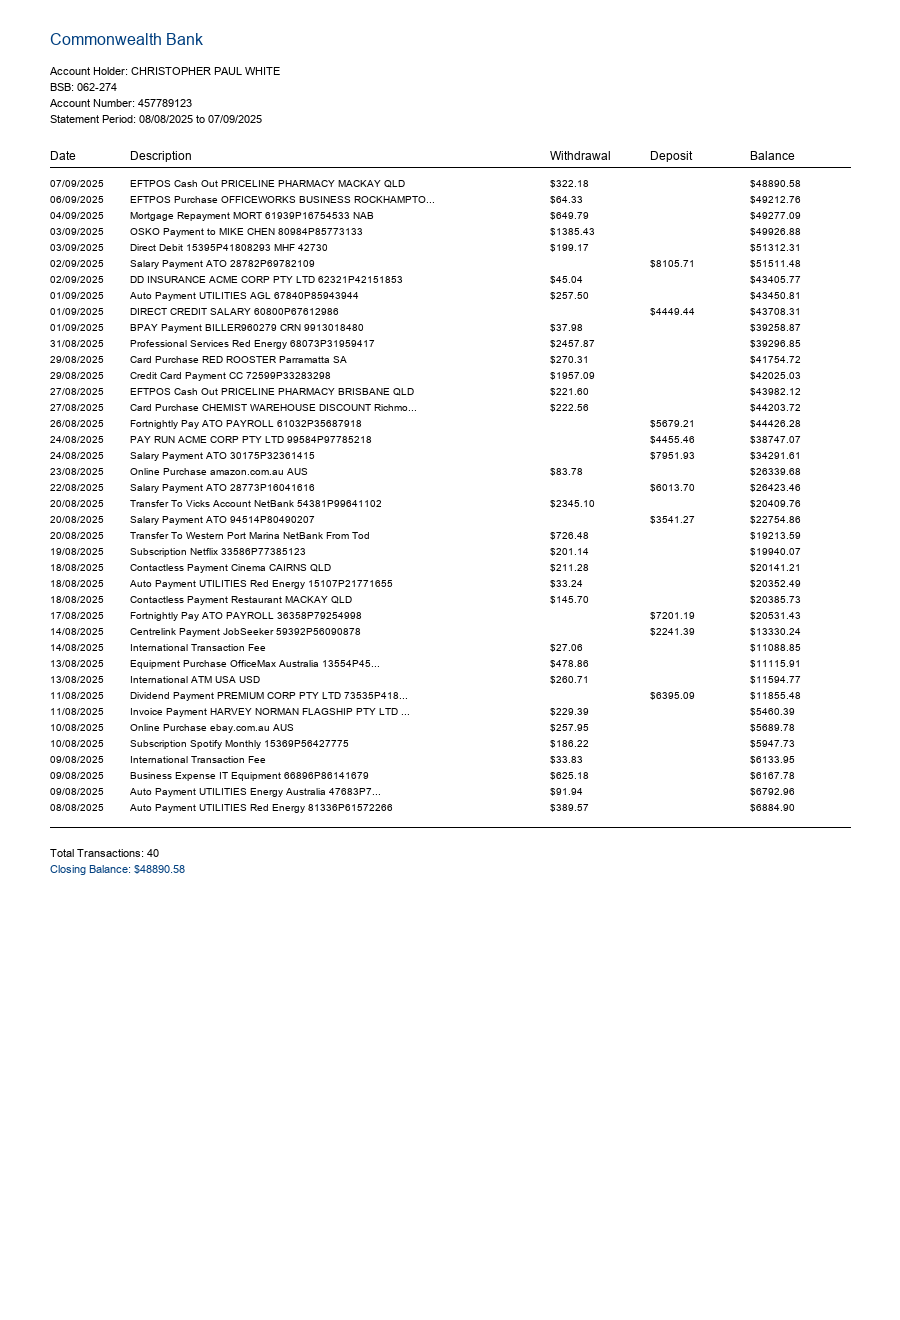

✅ Compare extraction results above with the visual BANK_STATEMENT image

In [8]:
# =============================================================================
# VISUAL COMPARISON - DOCUMENT IMAGE DISPLAY
# =============================================================================

from IPython.display import Image as IPImage
from IPython.display import display

if IMAGE_PATH and Path(IMAGE_PATH).exists():
    rprint(f"[cyan]📄 Displaying {DOCUMENT_TYPE} for visual comparison: {Path(IMAGE_PATH).name}[/cyan]")
    
    # Display the image
    display(IPImage(filename=IMAGE_PATH))
    
    rprint(f"[green]✅ Compare extraction results above with the visual {DOCUMENT_TYPE} image[/green]")
else:
    rprint(f"[red]❌ Document image not found: {IMAGE_PATH}[/red]")

# Field-Level Ground Truth Evaluation

Comprehensive field-by-field comparison between extracted data and ground truth values.

In [9]:
# =============================================================================
# RESPONSE PREPROCESSING - Import from common module
# =============================================================================

from common.response_preprocessing import (
    clean_markdown_response,
    extract_statement_date_range,
    extract_transaction_data_from_table,
    map_bank_fields_to_universal,
    map_invoice_fields_to_universal,
    map_receipt_fields_to_universal,
    map_fields_to_universal,  # Universal mapping function
)

rprint("[green]✅ Response preprocessing functions imported from common module[/green]")

✅ Response preprocessing functions imported from common module

# Ground Truth Evaluation Summary 

In [10]:
# =============================================================================
# FIELD-LEVEL GROUND TRUTH EVALUATION - DOCUMENT-AWARE
# =============================================================================

from common.ground_truth_evaluator import GroundTruthEvaluator

if IMAGE_PATH and 'test_result' in globals() and test_result.get('success'):
    # Perform comprehensive ground truth evaluation using the new module
    evaluator = GroundTruthEvaluator(GROUND_TRUTH_CSV)
    evaluation_results = evaluator.evaluate_extraction(
        test_result=test_result,
        document_type=DOCUMENT_TYPE,
        image_path=IMAGE_PATH
    )
else:
    rprint("[yellow]⚠️ No extraction results available for evaluation[/yellow]")
    rprint("[dim]Run the extraction test in the cell above first[/dim]")

📊 FIELD-LEVEL GROUND TRUTH EVALUATION

────────────────────────────────── Comprehensive Document-Aware Field Evaluation ──────────────────────────────────

DEBUG: Looking for date fields in 57 lines

DEBUG: Found earliest date: 07/09/2025

DEBUG: Found latest date: 08/08/2025

...

Note: Using bank_statement-specific extraction with field mapping

❌ POOR - Major improvements required (<75% accuracy)

⏱️  Processing Time: 178.49s

  Speed: Needs optimization (>10s)

───────────────────────────────────────── Field-Level Evaluation Complete ─────────────────────────────────────────